In [9]:
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
from dataset import ISBIVesselDataset3D, make_isbi_dataloaders
import matplotlib.pyplot as plt
import os
import torch.multiprocessing as mp
from torch.utils.data import DistributedSampler, DataLoader
from MiniDiLoCo.train import Trainer, diloco_worker
from MiniDiLoCo.strategy import Diloco
from MiniDiLoCo.utils import setup, cleanup
from UNet3D import UNet3D
import torch
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.ndimage import distance_transform_edt
import PIL.Image as PILImage
import base64, io
from skimage.morphology import skeletonize
from MiniDiLoCo.clmr import CLMR
from lion_pytorch import Lion
import json
import time

In [2]:
import torch
from collections import defaultdict

# Assure-toi que ton modèle UNet3D est déjà défini/importé, puis :
unet3d = UNet3D(1, 1)

def count_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

# Détail par bloc nommé (top-level)
print("=== Paramètres par bloc ===")
total = 0
for name, module in unet3d.named_children():
    n = count_params(module)
    total += n
    print(f"{name:10s} : {n:>12,} paramètres")

print(f"\nTotal (top-level) : {total:,}")
print(f"Total (via model.parameters()) : {count_params(unet3d):,}")

# Regroupement encodeur / décodeur / sortie
encoder = sum(count_params(getattr(unet3d, n)) for n in ['inc', 'down1', 'down2', 'down3', 'down4'])
decoder = sum(count_params(getattr(unet3d, n)) for n in ['up1', 'up2', 'up3', 'up4'])
outc = count_params(unet3d.outc)

print(f"\n=== Regroupement ===")
print(f"Encodeur (inc + down1-4) : {encoder:,}")
print(f"Décodeur (up1-4)         : {decoder:,}")
print(f"Couche de sortie (outc)  : {outc:,}")
print(f"Somme                    : {encoder + decoder + outc:,}")

# Détail encore plus fin (par sous-module de chaque bloc)
print(f"\n=== Détail fin par sous-couche ===")
for name, module in unet3d.named_modules():
    n_params = sum(p.numel() for p in module.parameters(recurse=False) if p.requires_grad)
    if n_params > 0:
        print(f"{name:30s} : {n_params:>10,}")

=== Paramètres par bloc ===
inc        :       28,704 paramètres
down1      :      166,272 paramètres
down2      :      664,320 paramètres
down3      :    2,655,744 paramètres
down4      :   10,619,904 paramètres
up1        :    6,358,784 paramètres
up2        :    1,590,144 paramètres
up3        :      397,760 paramètres
up4        :       99,552 paramètres
outc       :           33 paramètres

Total (top-level) : 22,581,217
Total (via model.parameters()) : 22,581,217

=== Regroupement ===
Encodeur (inc + down1-4) : 14,134,944
Décodeur (up1-4)         : 8,446,240
Couche de sortie (outc)  : 33
Somme                    : 22,581,217

=== Détail fin par sous-couche ===
inc.double_conv.0              :        896
inc.double_conv.1              :         64
inc.double_conv.3              :     27,680
inc.double_conv.4              :         64
down1.maxpool_conv.1.double_conv.0 :     55,360
down1.maxpool_conv.1.double_conv.1 :        128
down1.maxpool_conv.1.double_conv.3 :    110,656
down1

# Métriques

In [10]:
def dice_score(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    target = target.float()
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return ((2 * inter + eps) / (union + eps)).item()


def sensitivity_score(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    target = target.float()
    tp = (pred * target).sum()
    fn = ((1 - pred) * target).sum()
    return ((tp + eps) / (tp + fn + eps)).item()


def cl_dice_score(pred, target, eps=1e-6):
    pred_np = (pred > 0.5).cpu().numpy().astype(np.uint8)
    target_np = target.cpu().numpy().astype(np.uint8)

    def cl_score(v, s):
        return (v * s).sum() / (s.sum() + eps)

    skel_pred = skeletonize(pred_np)
    skel_target = skeletonize(target_np)

    t_prec = cl_score(pred_np, skel_target)
    t_sens = cl_score(target_np, skel_pred)
    return (2 * t_prec * t_sens / (t_prec + t_sens + eps))


def hd95_score(pred, target):
    pred_np = (pred > 0.5).cpu().numpy().astype(bool)
    target_np = target.cpu().numpy().astype(bool)

    if pred_np.sum() == 0 or target_np.sum() == 0:
        return float("nan")

    dt_target = distance_transform_edt(~target_np)
    dt_pred = distance_transform_edt(~pred_np)

    d_pred_to_target = dt_target[pred_np]
    d_target_to_pred = dt_pred[target_np]

    all_d = np.concatenate([d_pred_to_target, d_target_to_pred])
    return float(np.percentile(all_d, 95))

# Pipeline UNet 3D

## Config

In [4]:
WORLD_SIZE = 1
NUM_EPOCHS = 1000
BATCH_SIZE = 1
LR = 0.01
SAVE_PATH = str(Path("models_checkpoints/UNet3D_solo.pth"))
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

In [5]:
print(f"{DEVICE} - {torch.cuda.get_device_name(2)}")

cuda:2 - NVIDIA GeForce GTX 1080


## Dataloader

In [6]:
train_dl, val_dl = make_isbi_dataloaders(
    dataset_root="dataset_isbi/",
    depth=16,
    img_size=(512, 320),
    train_ratio=0.8,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(f"train_dl size: {len(train_dl)}")
batch = next(iter(train_dl))
volume = batch["pixel_values"]
mask = batch["labels"]
print(f"Volume shape : {volume.shape}")
print(f"Mask shape   : {mask.shape}")

145 cas trouvés
Train: 116 cas -> 464 échantillons (x4)
Val:   29 cas -> 29 échantillons
train_dl size: 464
Volume shape : torch.Size([1, 1, 16, 320, 512])
Mask shape   : torch.Size([1, 1, 16, 320, 512])


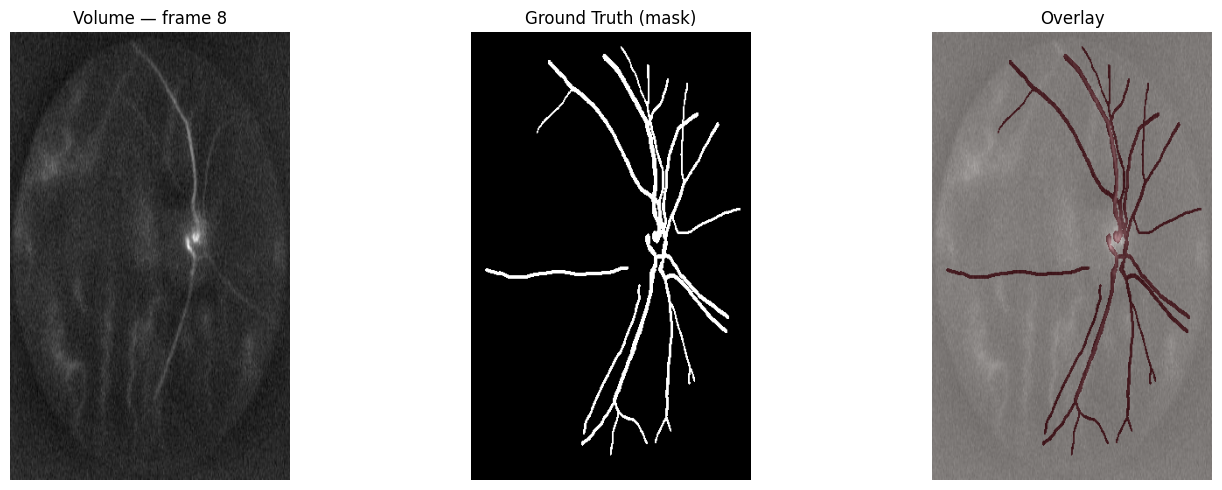

In [7]:
batch = next(iter(train_dl))  # (B, 1, D, H, W)

vol = batch["pixel_values"][0, 0].cpu().numpy()  # (D, H, W)
msk = batch["labels"][0, 0].cpu().numpy()        # (D, H, W)

# Affichage du sample
mid = vol.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(vol[mid], cmap='gray')
axes[0].set_title(f"Volume — frame {mid}")
axes[0].axis('off')

axes[1].imshow(msk[mid], cmap='gray')
axes[1].set_title("Ground Truth (mask)")
axes[1].axis('off')

axes[2].imshow(vol[mid], cmap='gray')
axes[2].imshow(msk[mid], cmap='Reds', alpha=0.4)
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Distributed training

In [8]:
Path("models_checkpoints").mkdir(exist_ok=True)
dataset = train_dl.dataset

# Loss
loss_fn = torch.nn.BCEWithLogitsLoss()

# Model
unet3d = UNet3D(1, 1)
unet3d.share_memory()

# Optimizers
inner_optimizer_cls    = torch.optim.SGD
inner_optimizer_kwargs = {"lr": 0.01, "momentum": 0.9, "nesterov": True}

outer_optimizer_cls    = torch.optim.SGD
outer_optimizer_kwargs = {"lr": 0.7, "momentum": 0.9, "nesterov": True}

# Lancement
os.environ['MASTER_ADDR'] = 'localhost'
os.environ['MASTER_PORT'] = '12356'

MODE = "full"  # "chunked" ou "full"

if WORLD_SIZE == 1:
    os.environ['LOCAL_RANK'] = '0'
    os.environ['WORLD_SIZE'] = '1'

    diloco_worker(
        rank=0,
        world_size=1,
        model=unet3d,
        dataset=dataset,
        batch_size=BATCH_SIZE,
        loss_fn=loss_fn,
        num_epochs=NUM_EPOCHS,
        lr=LR,
        save_path=SAVE_PATH,
        inner_optimizer_cls=inner_optimizer_cls,
        inner_optimizer_kwargs=inner_optimizer_kwargs,
        outer_optimizer_cls=outer_optimizer_cls,
        outer_optimizer_kwargs=outer_optimizer_kwargs,
        mode=MODE,
    )
else:
    mp.spawn(
        diloco_worker,
        args=(
            WORLD_SIZE, unet3d, dataset, BATCH_SIZE, loss_fn,
            NUM_EPOCHS, LR, SAVE_PATH,
            inner_optimizer_cls, inner_optimizer_kwargs,
            outer_optimizer_cls, outer_optimizer_kwargs,
            MODE,
        ),
        nprocs=WORLD_SIZE,
        join=True,
    )

print(f"✅ Entraînement terminé — modèle sauvegardé : {SAVE_PATH}")

Rank 0: DiLoCo H=464
TAILLE DU DATALOADER: 464
Rank: 2 - Outer step: 0 - Average loss: 0.1665959730583789
Rank: 2 - Outer step: 1 - Average loss: 0.10253005169717402
Rank: 2 - Outer step: 2 - Average loss: 0.08734214981086552
Rank: 2 - Outer step: 3 - Average loss: 0.07941753515202937
Rank: 2 - Outer step: 4 - Average loss: 0.0735991992184828
Rank: 2 - Outer step: 5 - Average loss: 0.06891310141132824
Rank: 2 - Outer step: 6 - Average loss: 0.0647280827839056
Rank: 2 - Outer step: 7 - Average loss: 0.0606310980811972
Rank: 2 - Outer step: 8 - Average loss: 0.05721511747607769
Rank: 2 - Outer step: 9 - Average loss: 0.05430499306109188
Rank: 2 - Outer step: 10 - Average loss: 0.05155160329465208
Rank: 2 - Outer step: 11 - Average loss: 0.04893997333269438
Rank: 2 - Outer step: 12 - Average loss: 0.04667540273131353
Rank: 2 - Outer step: 13 - Average loss: 0.04408858630179974
Rank: 2 - Outer step: 14 - Average loss: 0.04161266968906697
Rank: 2 - Outer step: 15 - Average loss: 0.039128422

/home/saxel/DopplerHolographySegmentationTraining/.venv/lib/python3.12/site-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


# Pipelin d'origine UNet 2D

## Config

In [15]:
print(f"Nombre de GPU disponibles : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"cuda:{i} → {torch.cuda.get_device_name(i)}")

print(f"\nGPU actuellement sélectionné : cuda:{torch.cuda.current_device()}")

Nombre de GPU disponibles : 3
cuda:0 → Quadro P6000
cuda:1 → NVIDIA GeForce GTX 1080 Ti
cuda:2 → NVIDIA GeForce GTX 1080

GPU actuellement sélectionné : cuda:0


In [18]:
NUM_EPOCHS = 1000
BATCH_SIZE = 1
SAVE_PATH = str(Path("models_checkpoints/UNet2D_pipeline.pth"))
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

In [19]:
DEVICE

device(type='cuda', index=2)

## Dataloader

In [12]:
import cv2
import numpy as np
import torch
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader


class ISBIVesselDataset2D(Dataset):
    def __init__(self, case_dirs, img_size=(256, 256), augment=False,
                 rotations=(0, 90, 180, 270)):
        self.case_dirs = [Path(d) for d in case_dirs]
        self.img_size = img_size
        self.augment = augment
        self.rotations = rotations if augment else (0,)

        self.index = [
            (case_dir, angle)
            for case_dir in self.case_dirs
            for angle in self.rotations
        ]

    def __len__(self):
        return len(self.index)

    def _find_m0_image(self, case_dir):
        avis = list(case_dir.glob("*.avi"))
        if not avis:
            raise FileNotFoundError(f"Aucun .avi dans {case_dir}")
        avi_path = avis[0]
        m0_path = avi_path.with_suffix(".png")
        if not m0_path.exists():
            raise FileNotFoundError(f"Aucun M0 trouvé : {m0_path}")
        return m0_path

    def _load_image(self, image_path):
        img = np.array(Image.open(image_path).convert("L"))
        img = cv2.resize(img, (self.img_size[1], self.img_size[0]))
        img = img.astype(np.float32) / 255.0
        return img  # (H, W)

    def _load_mask(self, mask_path):
        mask = np.array(Image.open(mask_path).convert("L"))
        mask = cv2.resize(mask, (self.img_size[1], self.img_size[0]),
                          interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)
        return mask  # (H, W)

    def _rotate(self, arr, angle):
        if angle == 0:
            return arr
        k = angle // 90
        return np.rot90(arr, k=k, axes=(0, 1)).copy()

    def __getitem__(self, idx):
        case_dir, angle = self.index[idx]
        m0_path = self._find_m0_image(case_dir)
        mask_path = case_dir / "manual" / "forceMaskVessel.png"

        image = self._load_image(m0_path)      # (H, W)
        mask = self._load_mask(mask_path)       # (H, W)

        image = self._rotate(image, angle)
        mask = self._rotate(mask, angle)

        image = torch.from_numpy(image).unsqueeze(0)  # (1, H, W)
        mask = torch.from_numpy(mask).unsqueeze(0)     # (1, H, W)

        return {"pixel_values": image, "labels": mask}


def make_isbi_dataloaders_2d(dataset_root, img_size=(256, 256),
                              train_ratio=0.8, batch_size=2, num_workers=0, seed=42,
                              augment_train=True, rotations=(0, 90, 180, 270)):
    dataset_root = Path(dataset_root)
    case_dirs = sorted([d for d in dataset_root.iterdir()
                        if d.is_dir() and list(d.glob("*.avi"))])
    if not case_dirs:
        raise FileNotFoundError(f"Aucun cas trouvé dans {dataset_root}")

    print(f"{len(case_dirs)} cas trouvés")

    n_train = max(1, int(len(case_dirs) * train_ratio))
    rng = np.random.default_rng(seed)
    shuffled = list(rng.permutation(len(case_dirs)))
    train_dirs = [case_dirs[i] for i in shuffled[:n_train]]
    val_dirs   = [case_dirs[i] for i in shuffled[n_train:]]

    train_ds = ISBIVesselDataset2D(
        train_dirs, img_size=img_size,
        augment=augment_train, rotations=rotations
    )
    val_ds = ISBIVesselDataset2D(
        val_dirs, img_size=img_size,
        augment=False
    )

    print(f"Train: {len(train_dirs)} cas -> {len(train_ds)} échantillons (x{len(rotations) if augment_train else 1})")
    print(f"Val:   {len(val_dirs)} cas -> {len(val_ds)} échantillons")

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return train_dl, val_dl

In [13]:
train_dl, val_dl = make_isbi_dataloaders_2d(
    dataset_root="dataset_isbi/",
    img_size=(512, 320),
    train_ratio=0.8,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(f"train_dl size: {len(train_dl)}")
batch = next(iter(train_dl))
image = batch["pixel_values"]
mask = batch["labels"]
print(f"Image shape : {image.shape}")
print(f"Mask shape  : {mask.shape}")

145 cas trouvés
Train: 116 cas -> 464 échantillons (x4)
Val:   29 cas -> 29 échantillons
train_dl size: 464
Image shape : torch.Size([1, 1, 512, 320])
Mask shape  : torch.Size([1, 1, 512, 320])


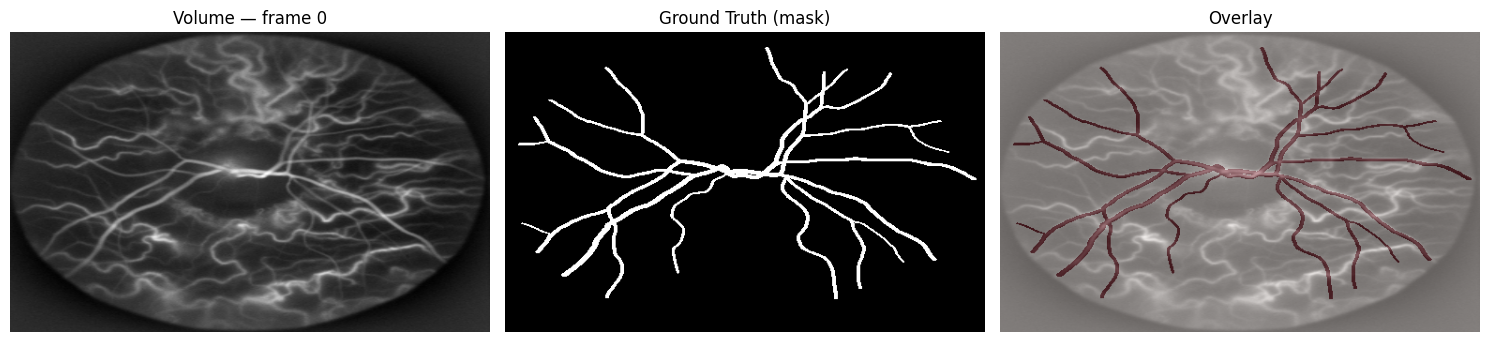

In [22]:
batch = next(iter(train_dl))  # (B, 1, D, H, W)

vol = batch["pixel_values"][0].cpu().numpy()  # (D, H, W)
msk = batch["labels"][0].cpu().numpy()        # (D, H, W)

# Affichage du sample
mid = vol.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(vol[mid], cmap='gray')
axes[0].set_title(f"Volume — frame {mid}")
axes[0].axis('off')

axes[1].imshow(msk[mid], cmap='gray')
axes[1].set_title("Ground Truth (mask)")
axes[1].axis('off')

axes[2].imshow(vol[mid], cmap='gray')
axes[2].imshow(msk[mid], cmap='Reds', alpha=0.4)
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [23]:
import time
import json
from models.custom_unet.unet import UNet

Path("models_checkpoints").mkdir(exist_ok=True)
dataset = train_dl.dataset

loss_fn = torch.nn.BCEWithLogitsLoss()
unet2d = UNet(1, 1).to(DEVICE)
optimizer = torch.optim.AdamW(
    unet2d.parameters(), lr=1e-3, betas=(0.9, 0.99), weight_decay=1e-2
)

print(f"TAILLE DU DATALOADER: {len(dataset)}")
max_hours = 5
start_time = time.time()
loss_history = []

unet2d.train()

for epoch in range(NUM_EPOCHS):
    running_loss = 0.0
    n_batches = 0

    for batch in train_dl:
        images = batch["pixel_values"].to(DEVICE)
        masks = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        logits = unet2d(images)
        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1

    avg_loss = running_loss / n_batches
    loss_history.append(avg_loss)
    elapsed = time.time() - start_time

    print(f"{DEVICE} - Epoch: {epoch} - Loss: {avg_loss:.6f} - Temps écoulé: {elapsed/3600:.2f}h")

    if elapsed >= max_hours * 3600:
        print(f"Arrêt après {max_hours}h (epoch {epoch})")
        break

torch.save(unet2d.state_dict(), SAVE_PATH)

loss_path = SAVE_PATH.replace(".pth", "_loss.json")
with open(loss_path, "w") as f:
    json.dump(loss_history, f)

print(f"✅ Modèle sauvegardé : {SAVE_PATH}")

TAILLE DU DATALOADER: 464
cuda:2 - Epoch: 0 - Loss: 0.172607 - Temps écoulé: 0.02h
cuda:2 - Epoch: 1 - Loss: 0.104407 - Temps écoulé: 0.03h
cuda:2 - Epoch: 2 - Loss: 0.090810 - Temps écoulé: 0.05h
cuda:2 - Epoch: 3 - Loss: 0.083691 - Temps écoulé: 0.07h
cuda:2 - Epoch: 4 - Loss: 0.078563 - Temps écoulé: 0.09h
cuda:2 - Epoch: 5 - Loss: 0.075611 - Temps écoulé: 0.10h
cuda:2 - Epoch: 6 - Loss: 0.072240 - Temps écoulé: 0.12h
cuda:2 - Epoch: 7 - Loss: 0.070825 - Temps écoulé: 0.14h
cuda:2 - Epoch: 8 - Loss: 0.069679 - Temps écoulé: 0.16h
cuda:2 - Epoch: 9 - Loss: 0.067472 - Temps écoulé: 0.18h
cuda:2 - Epoch: 10 - Loss: 0.066967 - Temps écoulé: 0.19h
cuda:2 - Epoch: 11 - Loss: 0.066026 - Temps écoulé: 0.21h
cuda:2 - Epoch: 12 - Loss: 0.064415 - Temps écoulé: 0.23h
cuda:2 - Epoch: 13 - Loss: 0.063881 - Temps écoulé: 0.25h
cuda:2 - Epoch: 14 - Loss: 0.062647 - Temps écoulé: 0.26h
cuda:2 - Epoch: 15 - Loss: 0.062236 - Temps écoulé: 0.28h
cuda:2 - Epoch: 16 - Loss: 0.061672 - Temps écoulé: 0.30

# Benchmark UNet2D vs UNet3D

## Load dataset

In [14]:
train_dl, val_dl = make_isbi_dataloaders(
    dataset_root="dataset_isbi/",
    depth=16,
    img_size=(512, 320),
    train_ratio=0.8,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

train_dl_2d, val_dl_2d = make_isbi_dataloaders_2d(
    dataset_root="dataset_isbi/",
    img_size=(512, 320),
    train_ratio=0.8,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(f"val_dl size    : {len(val_dl)}")
print(f"val_dl_2d size : {len(val_dl_2d)}")

145 cas trouvés
Train: 116 cas -> 464 échantillons (x4)
Val:   29 cas -> 29 échantillons
145 cas trouvés
Train: 116 cas -> 464 échantillons (x4)
Val:   29 cas -> 29 échantillons
val_dl size    : 29
val_dl_2d size : 29


In [17]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
from models.custom_unet.unet import UNet

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"{device} - {torch.cuda.get_device_name(0)}")

loss_fn = torch.nn.BCEWithLogitsLoss()

def evaluate_full(model, val_dl, device, loss_fn):
    model.eval()
    dices, sens, cldices, cldices_fw, hd95s, hd95s_fw, losses = [], [], [], [], [], [], []

    with torch.no_grad():
        for batch in val_dl:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            logits = model(pixel_values)
            loss = loss_fn(logits, labels)
            losses.append(loss.item())

            preds = torch.sigmoid(logits)

            for b in range(preds.shape[0]):
                p, t = preds[b, 0], labels[b, 0]
                dices.append(dice_score(p, t))
                sens.append(sensitivity_score(p, t))
                cldices.append(cl_dice_score(p, t))
                hd95s.append(hd95_score(p, t))

    print(losses)
    model.train()
    return {
        "final_loss": float(np.mean(losses)),
        "dice": float(np.nanmean(dices)),
        "sensitivity": float(np.nanmean(sens)),
        "cl_dice": float(np.nanmean(cldices)),
        "hd95": float(np.nanmean(hd95s))
    }


unet3d = UNet3D(1, 1)
unet3d.load_state_dict(torch.load("models_checkpoints/UNet3D_solo.pth", weights_only=True))
unet3d.to(device)

unet2d = UNet(1, 1)
unet2d.load_state_dict(torch.load("models_checkpoints/UNet2D_pipeline.pth", weights_only=True))
unet2d.to(device)

results_3d = evaluate_full(unet3d, val_dl, device, loss_fn)
results_2d = evaluate_full(unet2d, val_dl_2d, device, loss_fn)

df = pd.DataFrame([
    {"model": "UNet3D", **results_3d},
    {"model": "UNet2D", **results_2d},
])

Path("output").mkdir(exist_ok=True)
df.to_csv("output/model_comparison.csv", index=False)
df

cuda:0 - Quadro P6000
[0.194831982254982, 0.201923206448555, 0.20674963295459747, 0.2917127013206482, 0.18258340656757355, 0.22148123383522034, 0.1885698437690735, 0.17331106960773468, 0.46423521637916565, 0.2564670741558075, 0.20852671563625336, 0.20243807137012482, 0.19729948043823242, 0.14071643352508545, 0.16512055695056915, 0.17973364889621735, 0.45995283126831055, 0.20777146518230438, 0.1858961433172226, 0.20784826576709747, 0.31199732422828674, 0.22071288526058197, 0.2702553868293762, 0.19418983161449432, 0.22912505269050598, 0.17813937366008759, 0.12442813068628311, 0.2784896492958069, 0.21024246513843536]
[0.19520585238933563, 0.12635360658168793, 0.19720731675624847, 0.20290933549404144, 0.1486266404390335, 0.13761194050312042, 0.15063396096229553, 0.1488928645849228, 0.3385823369026184, 0.13790862262248993, 0.1864236295223236, 0.1950724869966507, 0.13776029646396637, 0.12430589646100998, 0.09777899831533432, 0.1545240730047226, 0.17870847880840302, 0.186052143573761, 0.20148

,model,final_loss,dice,sensitivity,cl_dice,hd95
0,UNet3D,0.226026,0.682917,0.725483,0.762436,22.41712
1,UNet2D,0.179384,0.698461,0.635041,0.804518,12.07460


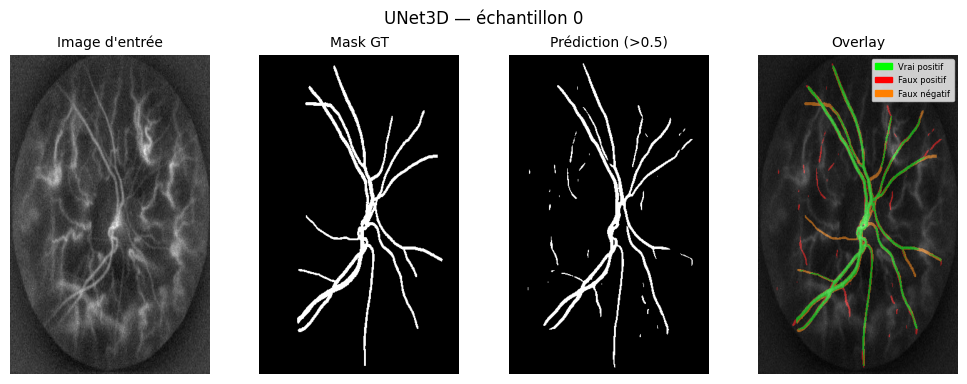

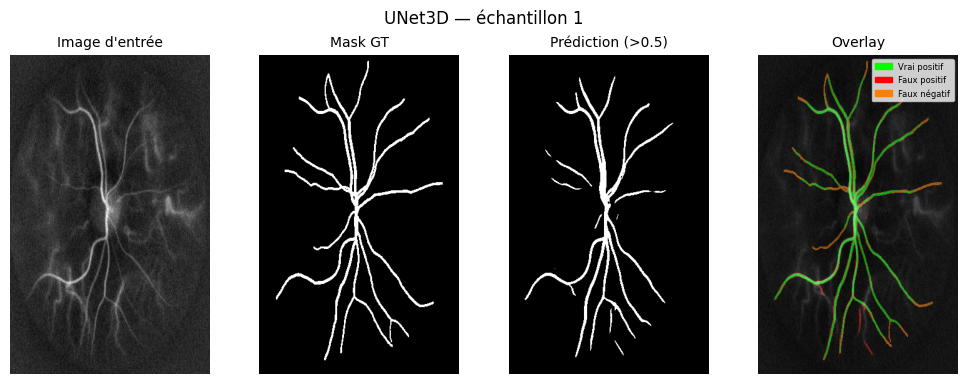

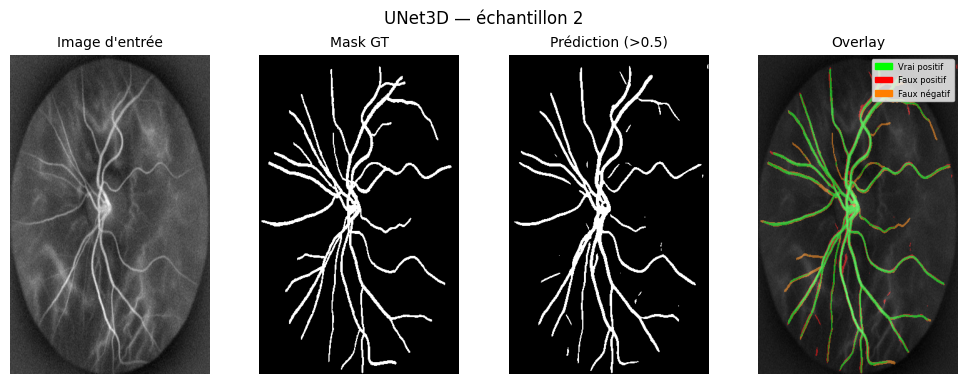

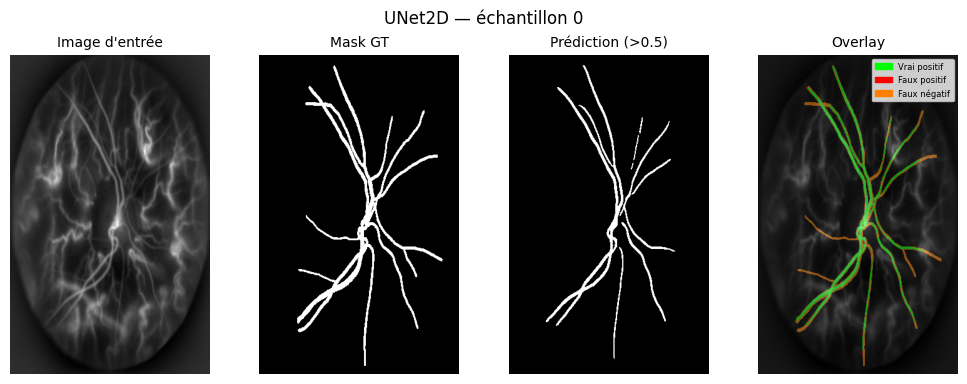

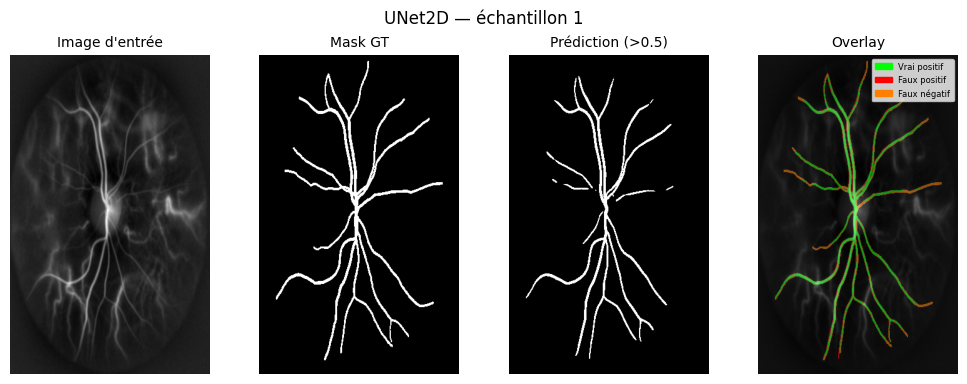

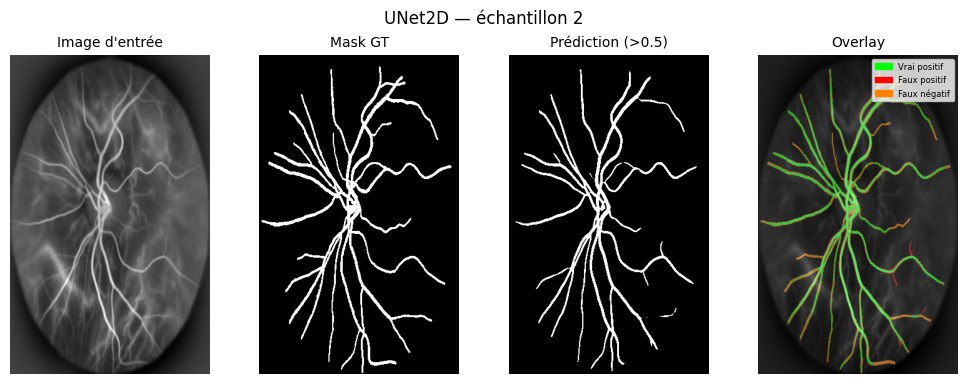

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def make_overlay(pred_bin, target, threshold=0.5):
    pred_bin = pred_bin > threshold
    target = target > 0.5

    overlay = np.zeros((*pred_bin.shape, 3), dtype=np.float32)
    tp = pred_bin & target
    fp = pred_bin & ~target
    fn = ~pred_bin & target

    overlay[tp] = [0, 1, 0]     # vert = vrai positif
    overlay[fp] = [1, 0, 0]     # rouge = faux positif
    overlay[fn] = [1, 0.5, 0]   # orange = faux négatif

    return overlay


def plot_predictions(model, val_dl, device, model_name, is_3d, num_samples=3, threshold=0.5):
    model.eval()
    save_dir = Path(f"output/predictions_{model_name}")
    save_dir.mkdir(parents=True, exist_ok=True)

    count = 0
    with torch.no_grad():
        for batch in val_dl:
            if count >= num_samples:
                break

            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            logits = model(pixel_values)
            preds = torch.sigmoid(logits)

            for b in range(pixel_values.shape[0]):
                if count >= num_samples:
                    break

                if is_3d:
                    mid = pixel_values.shape[2] // 2
                    img = pixel_values[b, 0, mid].cpu().numpy()
                    gt = labels[b, 0, mid].cpu().numpy()
                    pred_proba = preds[b, 0, mid].cpu().numpy()
                else:
                    img = pixel_values[b, 0].cpu().numpy()
                    gt = labels[b, 0].cpu().numpy()
                    pred_proba = preds[b, 0].cpu().numpy()

                pred_bin = pred_proba > threshold
                overlay = make_overlay(pred_bin, gt, threshold)

                # Figure plus compacte : moins de marge globale
                fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))

                axes[0].imshow(img, cmap="gray")
                axes[0].set_title("Image d'entrée", fontsize=10)
                axes[0].axis("off")

                axes[1].imshow(gt, cmap="gray")
                axes[1].set_title("Mask GT", fontsize=10)
                axes[1].axis("off")

                axes[2].imshow(pred_bin, cmap="gray")
                axes[2].set_title(f"Prédiction (>{threshold})", fontsize=10)
                axes[2].axis("off")

                axes[3].imshow(img, cmap="gray")
                axes[3].imshow(overlay, alpha=0.5)
                axes[3].set_title("Overlay", fontsize=10)
                axes[3].axis("off")

                handles = [
                    mpatches.Patch(color=[0, 1, 0], label="Vrai positif"),
                    mpatches.Patch(color=[1, 0, 0], label="Faux positif"),
                    mpatches.Patch(color=[1, 0.5, 0], label="Faux négatif"),
                ]
                axes[3].legend(handles=handles, loc="upper right", fontsize=6)

                # --- Réduction des espaces blancs entre subplots ---
                fig.suptitle(f"{model_name} — échantillon {count}", fontsize=12, y=0.98)
                plt.subplots_adjust(
                    wspace=-0.6,   # espace horizontal quasi nul entre les 4 images
                    hspace=0.0,    # pas de ligne supplémentaire ici (1 seule rangée)
                    left=0.01, right=0.99,
                    top=0.86, bottom=0.02
                )

                plt.savefig(
                    save_dir / f"sample_{count}.png",
                    dpi=200,
                    bbox_inches="tight",
                    pad_inches=0.05
                )
                plt.show()
                plt.close()

                count += 1

    model.train()


plot_predictions(unet3d, val_dl, device, "UNet3D", is_3d=True, num_samples=3)
plot_predictions(unet2d, val_dl_2d, device, "UNet2D", is_3d=False, num_samples=3)